# 03 — IndoBERT Fine-Tuning (Revised)
## Aoranema Sentiment Analysis

Revisi utama:
- Pin `transformers==4.46.3`
- Gunakan satu GPU untuk batch size yang konsisten
- Tambahkan verifikasi integritas LayerNorm setelah save/reload
- Pertahankan dataset, split, seed, dan hyperparameter eksperimen sebelumnya
- Test set tetap tidak digunakan untuk pemilihan model

In [1]:
# ============================================================
# 0. INSTALL VERSI TRANSFORMERS YANG DIKUNCI
# Jalankan sebagai cell pertama sebelum import transformers.
# ============================================================

import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "transformers==4.46.3"
])

print("Transformers 4.46.3 selesai dipasang.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.7 MB/s eta 0:00:00
Transformers 4.46.3 selesai dipasang.


In [2]:
# ============================================================
# 1. IMPORT LIBRARY & KONFIGURASI DEVICE
# ============================================================

import os

# Pakai satu GPU agar batch size eksperimen benar-benar konsisten.
# Harus ditetapkan sebelum import torch.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from pathlib import Path
import json
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42

set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("PyTorch      :", torch.__version__)
print("Transformers :", transformers.__version__)
print("CUDA tersedia:", torch.cuda.is_available())
print("Jumlah GPU   :", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

assert transformers.__version__ == "4.46.3", (
    f"Versi Transformers tidak sesuai: {transformers.__version__}"
)

PyTorch      : 2.10.0+cu128
Transformers : 4.46.3
CUDA tersedia: True
Jumlah GPU   : 1
GPU          : Tesla T4


In [3]:
# ============================================================
# 2. KONFIGURASI EKSPERIMEN
# ============================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"

MAX_LENGTH = 128
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10

LABEL_ORDER = ["negative", "neutral", "positive"]

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

print("Model        :", MODEL_NAME)
print("Max length   :", MAX_LENGTH)
print("Learning rate:", LEARNING_RATE)
print("Epoch        :", NUM_EPOCHS)
print("Train batch  :", TRAIN_BATCH_SIZE)
print("Eval batch   :", EVAL_BATCH_SIZE)
print("Label mapping:", label2id)

Model        : indobenchmark/indobert-base-p1
Max length   : 128
Learning rate: 2e-05
Epoch        : 3
Train batch  : 16
Eval batch   : 32
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [4]:
# ============================================================
# 3. CARI DATASET
# ============================================================

from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

# Cari semua CSV
csv_files = list(KAGGLE_INPUT.rglob("*.csv"))

print("CSV yang ditemukan di Kaggle Input:")

for i, path in enumerate(csv_files, start=1):
    print(f"{i}. {path}")

# Prioritas 1: nama persis sentiment_clean.csv
matches = [
    path for path in csv_files
    if path.name.lower() == "sentiment_clean.csv"
]

# Prioritas 2: nama file mengandung sentiment dan clean
if not matches:
    matches = [
        path for path in csv_files
        if "sentiment" in path.name.lower()
        and "clean" in path.name.lower()
    ]

if not matches:
    raise FileNotFoundError(
        "\nDataset sentiment_clean belum ditemukan.\n"
        "Tambahkan dataset/output Notebook 01 melalui Add Input di Kaggle."
    )

DATA_PATH = matches[0]

print("\nDataset yang digunakan:")
print(DATA_PATH)

CSV yang ditemukan di Kaggle Input:
1. /kaggle/input/datasets/onallaaldeanuva/sentiment-clean-csv/sentiment_clean.csv

Dataset yang digunakan:
/kaggle/input/datasets/onallaaldeanuva/sentiment-clean-csv/sentiment_clean.csv


In [5]:
# ============================================================
# 4. LOAD & VALIDASI DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

required_columns = {"content", "sentiment"}
valid_labels = set(LABEL_ORDER)

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_columns}")

assert df["content"].notna().all()
assert df["sentiment"].notna().all()
assert set(df["sentiment"].unique()).issubset(valid_labels)

print("Shape :", df.shape)
print("Kolom :", df.columns.tolist())
print("\nDistribusi kelas:")
display(df["sentiment"].value_counts().reindex(LABEL_ORDER).to_frame("count"))

display(df.head())

Shape : (21589, 2)
Kolom : ['content', 'sentiment']

Distribusi kelas:


,count
sentiment,
negative,7716
neutral,7423
positive,6450


,content,sentiment
0,bukan menyenangkan malah bikin kesal hp saya realme c 11 malah ngeblank hitam ga masuk keloading giliran udah masuk malah loading nya berhenti masuk juga mod nya kadang muncul ...,negative
1,"kalo ngak niat bikin gamenya bagus hapus aja dah gamenya, masa setiap narik atau mabar diconet mulu, kalo niat bikin game update ada apa saja bug pada game, kalo udah bener nta...",negative
2,"kntl, masa ada iklan ngga bisa di skip. Padahal perjalanan kurang 1 kota lagi. Jadi males main online, udah gitu mobil yang dari lawan arah tiba"" menabrak bis saya..terus juga ...",negative
3,"makin lama, makin gak jelas dri sblum di update game ini tiba tiba keluar sndiri tapi setelah di update 3.7 suka keluar sndiri di saat mau main, mana bnyak Bug tlong di perbaik...",negative
4,semenjak update sangat sangat buruk setiap main bareng sering disconeted padahal sinyal bagus cukup bintang satu aja untuk,negative


In [6]:
# ============================================================
# 5. SPLIT 80/10/10 — SAMA DENGAN NOTEBOOK 02
# ============================================================

X = df["content"].astype(str)
y = df["sentiment"].astype(str)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))
print("Total      :", len(X_train) + len(X_val) + len(X_test))

assert len(X_train) == 17271
assert len(X_val) == 2159
assert len(X_test) == 2159

Train      : 17271
Validation : 2159
Test       : 2159
Total      : 21589


In [7]:
# ============================================================
# 6. CEK DISTRIBUSI SPLIT
# ============================================================

def distribution_table(series, name):
    counts = series.value_counts().reindex(LABEL_ORDER)
    percent = (counts / counts.sum() * 100).round(2)

    return pd.DataFrame({
        f"{name}_count": counts,
        f"{name}_percent": percent
    })

split_distribution = pd.concat([
    distribution_table(y_train, "train"),
    distribution_table(y_val, "validation"),
    distribution_table(y_test, "test")
], axis=1)

display(split_distribution)

,train_count,train_percent,validation_count,validation_percent,test_count,test_percent
sentiment,,,,,,
negative,6173,35.74,771,35.71,772,35.76
neutral,5938,34.38,743,34.41,742,34.37
positive,5160,29.88,645,29.87,645,29.87


In [8]:
# ============================================================
# 7. SIMPAN SPLIT UNTUK NOTEBOOK 04
# ============================================================

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_split_df = pd.DataFrame({
    "content": X_train.values,
    "sentiment": y_train.values
})

validation_split_df = pd.DataFrame({
    "content": X_val.values,
    "sentiment": y_val.values
})

test_split_df = pd.DataFrame({
    "content": X_test.values,
    "sentiment": y_test.values
})

TRAIN_SPLIT_PATH = OUTPUT_DIR / "train_split.csv"
VAL_SPLIT_PATH = OUTPUT_DIR / "validation_split.csv"
TEST_SPLIT_PATH = OUTPUT_DIR / "test_split.csv"

train_split_df.to_csv(TRAIN_SPLIT_PATH, index=False)
validation_split_df.to_csv(VAL_SPLIT_PATH, index=False)
test_split_df.to_csv(TEST_SPLIT_PATH, index=False)

print("Split berhasil disimpan.")

Split berhasil disimpan.


In [9]:
# ============================================================
# 8. LOAD TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Tokenizer      :", tokenizer.__class__.__name__)
print("Vocabulary size:", tokenizer.vocab_size)

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer      : BertTokenizerFast
Vocabulary size: 30521


In [10]:
# ============================================================
# 9. AUDIT PANJANG TOKEN
# ============================================================

all_texts = df["content"].astype(str).tolist()

token_length_output = tokenizer(
    all_texts,
    add_special_tokens=True,
    truncation=False,
    padding=False,
    return_length=True
)

token_lengths = np.array(token_length_output["length"])

token_stats = pd.Series(token_lengths).describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

display(token_stats.to_frame("token_length").round(2))

over_limit = int((token_lengths > MAX_LENGTH).sum())
over_limit_percent = over_limit / len(token_lengths) * 100

print(
    f"Teks > {MAX_LENGTH} token:",
    f"{over_limit:,} ({over_limit_percent:.2f}%)"
)

,token_length
count,21589.00
mean,21.43
std,21.70
min,3.00
50%,13.00
75%,28.00
90%,50.00
95%,67.00
99%,102.00
max,308.00


Teks > 128 token: 36 (0.17%)


In [11]:
# ============================================================
# 10. KONVERSI KE HUGGING FACE DATASET
# ============================================================

def to_hf_dataset(texts, labels):
    return Dataset.from_dict({
        "text": list(texts),
        "labels": [label2id[label] for label in labels]
    })

train_dataset = to_hf_dataset(
    X_train.tolist(),
    y_train.tolist()
)

val_dataset = to_hf_dataset(
    X_val.tolist(),
    y_val.tolist()
)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['text', 'labels'],
    num_rows: 17271
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 2159
})


In [12]:
# ============================================================
# 11. TOKENISASI
# ============================================================

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_train = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing train"
)

tokenized_val = val_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing validation"
)

print(tokenized_train)
print(tokenized_val)

Tokenizing train:   0%|          | 0/17271 [00:00<?, ? examples/s]

Tokenizing validation:   0%|          | 0/2159 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 17271
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2159
})


In [13]:
# ============================================================
# 12. DYNAMIC PADDING
# ============================================================

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print(data_collator)

DataCollatorWithPadding(tokenizer=BertTokenizerFast(name_or_path='indobenchmark/indobert-base-p1', vocab_size=30521, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}, padding=True, max_length=None, pad_to_multiple_of=None, ret

In [14]:
# ============================================================
# 13. LOAD INDOBERT UNTUK 3-CLASS CLASSIFICATION
# ============================================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_ORDER),
    label2id=label2id,
    id2label=id2label
)

print("Model       :", model.__class__.__name__)
print("Jumlah label:", model.config.num_labels)

# Warning classifier.weight / classifier.bias MISSING di tahap ini NORMAL,
# karena classification head baru memang harus dilatih.

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model       : BertForSequenceClassification
Jumlah label: 3


In [15]:
# ============================================================
# 14. METRIC FUNCTION
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(accuracy),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1)
    }

In [16]:
# ============================================================
# 15. TRAINING ARGUMENTS
# ============================================================

TRAINER_OUTPUT_DIR = OUTPUT_DIR / "indobert_training"

training_args = TrainingArguments(
    output_dir=str(TRAINER_OUTPUT_DIR),

    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,

    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=1,

    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE,

    report_to="none",

    fp16=torch.cuda.is_available()
)

print(training_args)

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=42,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_us

In [17]:
# ============================================================
# 16. TRAINER
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("Trainer siap.")

/tmp/ipykernel_23/2015458278.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainer siap.


In [18]:
# ============================================================
# 17. FINE-TUNING
# ============================================================

train_result = trainer.train()

print("\nTraining selesai.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric    :", trainer.state.best_metric)

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.490400,0.440425,0.825845,0.829054,0.825329,0.826772
2,0.360500,0.417647,0.841593,0.847682,0.841739,0.843772
3,0.217600,0.487768,0.839741,0.840524,0.842006,0.841083



Training selesai.
Best checkpoint: /kaggle/working/indobert_training/checkpoint-2160
Best metric    : 0.8437719680516592


In [19]:
# ============================================================
# 18. EVALUASI BEST MODEL PADA VALIDATION
# ============================================================

val_metrics = trainer.evaluate(
    eval_dataset=tokenized_val
)

print("=== BEST MODEL — VALIDATION ===")

for key, value in val_metrics.items():
    if isinstance(value, (int, float)):
        print(f"{key:24s}: {value:.4f}")

=== BEST MODEL — VALIDATION ===
eval_loss               : 0.4176
eval_accuracy           : 0.8416
eval_macro_precision    : 0.8477
eval_macro_recall       : 0.8417
eval_macro_f1           : 0.8438
eval_runtime            : 2.7877
eval_samples_per_second : 774.4600
eval_steps_per_second   : 24.3920
epoch                   : 3.0000


In [20]:
# ============================================================
# 19. CLASSIFICATION REPORT — VALIDATION
# ============================================================

val_prediction_output = trainer.predict(
    tokenized_val
)

val_logits = val_prediction_output.predictions
val_label_ids = val_prediction_output.label_ids

val_pred_ids = np.argmax(
    val_logits,
    axis=-1
)

val_true_labels = [
    id2label[int(i)]
    for i in val_label_ids
]

val_pred_labels = [
    id2label[int(i)]
    for i in val_pred_ids
]

val_report_dict = classification_report(
    val_true_labels,
    val_pred_labels,
    labels=LABEL_ORDER,
    digits=4,
    zero_division=0,
    output_dict=True
)

display(
    pd.DataFrame(val_report_dict).transpose()
)

,precision,recall,f1-score,support
negative,0.873486,0.841764,0.857332,771.000000
neutral,0.767241,0.838493,0.801286,743.000000
positive,0.902318,0.844961,0.872698,645.000000
accuracy,0.841593,0.841593,0.841593,0.841593
macro avg,0.847682,0.841739,0.843772,2159.000000
weighted avg,0.845536,0.841593,0.842635,2159.000000


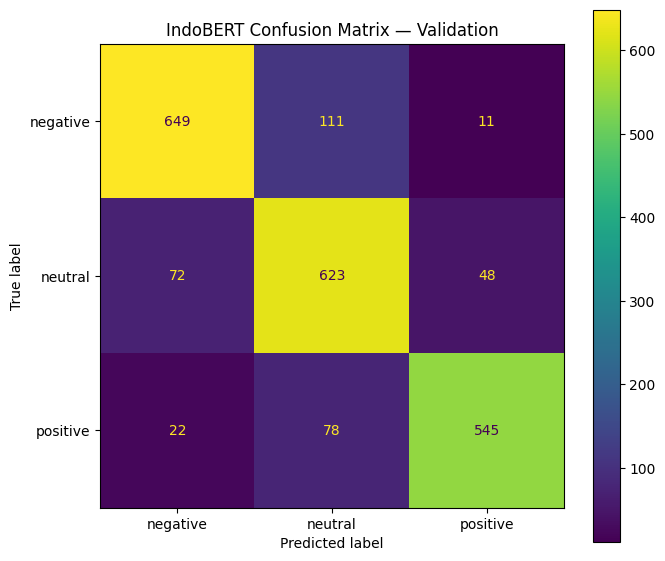

In [21]:
# ============================================================
# 20. CONFUSION MATRIX — VALIDATION
# ============================================================

cm_val = confusion_matrix(
    val_true_labels,
    val_pred_labels,
    labels=LABEL_ORDER
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=LABEL_ORDER
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("IndoBERT Confusion Matrix — Validation")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 21. TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    trainer.state.log_history
)

display(history_df.tail(20))

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
17,0.3642,3.927968,1.056241e-05,1.574074,1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,0.3593,15.176407,9.876543e-06,1.666667,1800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,0.3582,11.171576,9.190672e-06,1.759259,1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0.3288,14.607094,8.504801e-06,1.851852,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,0.3605,9.550881,7.818930e-06,1.944444,2100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,NaN,NaN,NaN,2.000000,2160,0.417647,0.841593,0.847682,0.841739,0.843772,2.8167,766.502,24.142,NaN,NaN,NaN,NaN,NaN
23,0.2882,9.218120,7.133059e-06,2.037037,2200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,0.2161,11.600901,6.447188e-06,2.129630,2300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,0.2281,8.821250,5.761317e-06,2.222222,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,0.2274,6.922521,5.082305e-06,2.314815,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


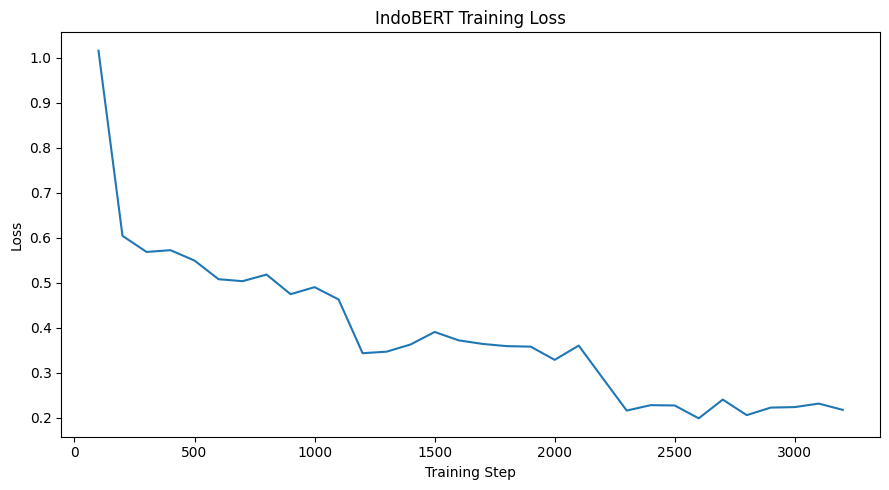

In [23]:
# ============================================================
# 22. GRAFIK TRAINING LOSS
# ============================================================

if "loss" in history_df.columns:
    train_loss_history = history_df[
        history_df["loss"].notna()
    ][["step", "loss"]].copy()

    if not train_loss_history.empty:
        plt.figure(figsize=(9, 5))
        plt.plot(
            train_loss_history["step"],
            train_loss_history["loss"]
        )
        plt.title("IndoBERT Training Loss")
        plt.xlabel("Training Step")
        plt.ylabel("Loss")
        plt.tight_layout()
        plt.show()

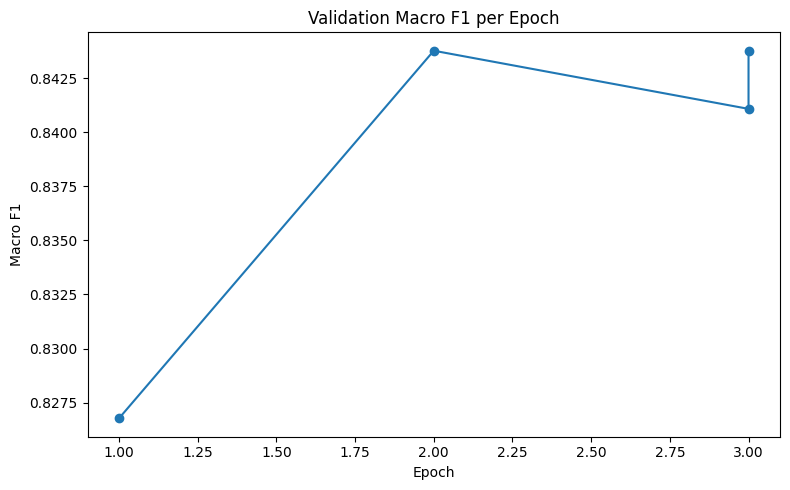

,epoch,eval_macro_f1
10,1.0,0.826772
22,2.0,0.843772
34,3.0,0.841083
36,3.0,0.843772


In [24]:
# ============================================================
# 23. GRAFIK VALIDATION MACRO F1
# ============================================================

if "eval_macro_f1" in history_df.columns:
    eval_history = history_df[
        history_df["eval_macro_f1"].notna()
    ][["epoch", "eval_macro_f1"]].copy()

    if not eval_history.empty:
        plt.figure(figsize=(8, 5))
        plt.plot(
            eval_history["epoch"],
            eval_history["eval_macro_f1"],
            marker="o"
        )
        plt.title("Validation Macro F1 per Epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Macro F1")
        plt.tight_layout()
        plt.show()

        display(eval_history)

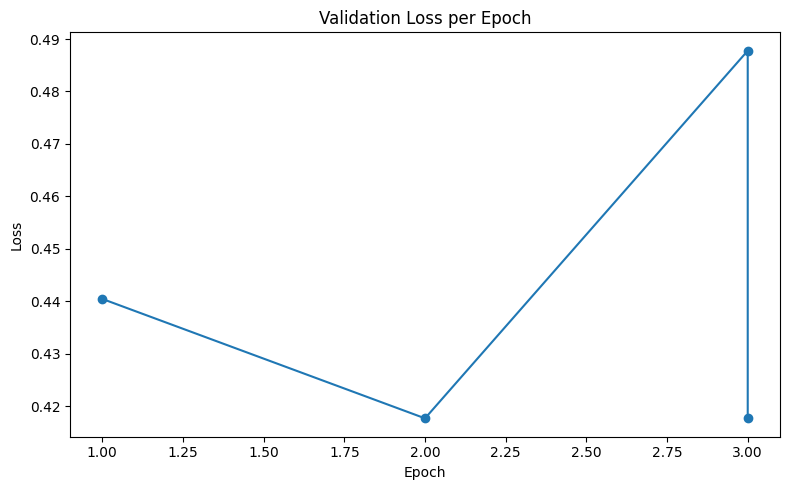

In [25]:
# ============================================================
# 24. GRAFIK VALIDATION LOSS
# ============================================================

if "eval_loss" in history_df.columns:
    eval_loss_history = history_df[
        history_df["eval_loss"].notna()
    ][["epoch", "eval_loss"]].copy()

    if not eval_loss_history.empty:
        plt.figure(figsize=(8, 5))
        plt.plot(
            eval_loss_history["epoch"],
            eval_loss_history["eval_loss"],
            marker="o"
        )
        plt.title("Validation Loss per Epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.tight_layout()
        plt.show()

In [26]:
# ============================================================
# 25. BANDINGKAN DENGAN BASELINE VALIDATION
# ============================================================

BASELINE_VAL_MACRO_F1 = 0.7729

indobert_val_macro_f1 = float(
    val_metrics.get("eval_macro_f1", np.nan)
)

comparison_val = pd.DataFrame({
    "model": [
        "TF-IDF + Logistic Regression",
        "IndoBERT"
    ],
    "validation_macro_f1": [
        BASELINE_VAL_MACRO_F1,
        indobert_val_macro_f1
    ]
})

display(comparison_val)

difference = (
    indobert_val_macro_f1
    - BASELINE_VAL_MACRO_F1
)

print(
    "Selisih IndoBERT - Baseline:",
    f"{difference:+.4f}"
)

,model,validation_macro_f1
0,TF-IDF + Logistic Regression,0.772900
1,IndoBERT,0.843772


Selisih IndoBERT - Baseline: +0.0709


In [27]:
# ============================================================
# 26. FUNGSI INFERENCE
# ============================================================

def predict_texts(
    texts,
    model,
    tokenizer,
    max_length=MAX_LENGTH
):
    device = next(model.parameters()).device

    encoded = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding=True,
        return_tensors="pt"
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**encoded)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    ).cpu().numpy()

    pred_ids = probabilities.argmax(axis=1)

    results = []

    for text, pred_id, probs in zip(
        texts,
        pred_ids,
        probabilities
    ):
        results.append({
            "text": text,
            "prediction": id2label[int(pred_id)],
            "confidence": float(probs[pred_id]),
            "negative_prob": float(probs[label2id["negative"]]),
            "neutral_prob": float(probs[label2id["neutral"]]),
            "positive_prob": float(probs[label2id["positive"]])
        })

    return pd.DataFrame(results)

In [28]:
# ============================================================
# 27. MANUAL TEST SEBELUM SAVE
# ============================================================

manual_texts = [
    "Proses booking tiketnya cepat dan gampang banget.",
    "Pembayaran QRIS sering gagal dan bikin kesal.",
    "Aplikasinya biasa saja, sejauh ini tidak ada masalah.",
    "Customer service sangat ramah dan membantu.",
    "Aplikasinya lemot banget setelah update.",
    "Tempat bioskopnya nyaman dan petugasnya ramah."
]

manual_before_save = predict_texts(
    manual_texts,
    trainer.model,
    tokenizer
)

print("Prediksi sebelum save:")
display(manual_before_save)

Prediksi sebelum save:


,text,prediction,confidence,negative_prob,neutral_prob,positive_prob
0,Proses booking tiketnya cepat dan gampang banget.,neutral,0.629356,0.002107,0.629356,0.368537
1,Pembayaran QRIS sering gagal dan bikin kesal.,negative,0.997512,0.997512,0.001693,0.000795
2,"Aplikasinya biasa saja, sejauh ini tidak ada masalah.",neutral,0.464016,0.270691,0.464016,0.265293
3,Customer service sangat ramah dan membantu.,neutral,0.844676,0.006011,0.844676,0.149313
4,Aplikasinya lemot banget setelah update.,negative,0.978132,0.978132,0.018091,0.003777
5,Tempat bioskopnya nyaman dan petugasnya ramah.,positive,0.684505,0.004241,0.311254,0.684505


In [29]:
# ============================================================
# 28. SIMPAN BEST MODEL
# ============================================================

FINAL_MODEL_DIR = OUTPUT_DIR / "indobert_sentiment_model"

trainer.save_model(
    str(FINAL_MODEL_DIR)
)

tokenizer.save_pretrained(
    str(FINAL_MODEL_DIR)
)

print("Model final tersimpan di:")
print(FINAL_MODEL_DIR)

Model final tersimpan di:
/kaggle/working/indobert_sentiment_model


In [30]:
# ============================================================
# 29. VERIFIKASI INTEGRITAS CHECKPOINT
# ============================================================

reloaded_model, loading_info = (
    AutoModelForSequenceClassification.from_pretrained(
        FINAL_MODEL_DIR,
        output_loading_info=True
    )
)

reloaded_tokenizer = AutoTokenizer.from_pretrained(
    FINAL_MODEL_DIR
)

missing_keys = loading_info.get("missing_keys", [])
unexpected_keys = loading_info.get("unexpected_keys", [])
mismatched_keys = loading_info.get("mismatched_keys", [])

missing_layernorm = [
    key for key in missing_keys
    if "LayerNorm" in key
]

unexpected_layernorm = [
    key for key in unexpected_keys
    if "LayerNorm" in key
]

print("Missing keys           :", missing_keys)
print("Unexpected keys        :", unexpected_keys)
print("Mismatched keys        :", mismatched_keys)
print("Missing LayerNorm      :", missing_layernorm)
print("Unexpected LayerNorm   :", unexpected_layernorm)

assert len(missing_layernorm) == 0, (
    "Ada bobot LayerNorm yang gagal dimuat."
)

assert len(unexpected_layernorm) == 0, (
    "Ada bobot LayerNorm yang tidak dikenali."
)

assert len(mismatched_keys) == 0, (
    "Ada bobot dengan shape yang tidak cocok."
)

print("\n✓ Integritas LayerNorm checkpoint aman.")

Missing keys           : []
Unexpected keys        : []
Mismatched keys        : []
Missing LayerNorm      : []
Unexpected LayerNorm   : []

✓ Integritas LayerNorm checkpoint aman.


In [31]:
# ============================================================
# 30. VERIFIKASI MODEL SETELAH SAVE / RELOAD
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

reloaded_model = reloaded_model.to(device)

# Prediksi menggunakan model yang sudah di-load ulang
manual_after_reload = predict_texts(
    manual_texts,
    reloaded_model,
    reloaded_tokenizer
)

comparison_predictions = pd.DataFrame({
    "text": manual_texts,
    "before_save": manual_before_save["prediction"],
    "after_reload": manual_after_reload["prediction"],
    "confidence_before": manual_before_save["confidence"],
    "confidence_after": manual_after_reload["confidence"]
})

comparison_predictions["confidence_diff"] = np.abs(
    comparison_predictions["confidence_before"]
    - comparison_predictions["confidence_after"]
)

display(comparison_predictions)

# ============================================================
# 1. Pastikan label prediksi tidak berubah
# ============================================================

same_predictions = (
    comparison_predictions["before_save"]
    == comparison_predictions["after_reload"]
).all()

print("Semua label prediksi sama:", same_predictions)

assert same_predictions, (
    "Ada label prediksi yang berubah setelah model di-load ulang."
)

# ============================================================
# 2. Lihat selisih confidence
# ============================================================

max_confidence_diff = float(
    comparison_predictions["confidence_diff"].max()
)

print(
    "Maximum confidence difference:",
    max_confidence_diff
)

# Toleransi lebih realistis untuk floating-point GPU
CONFIDENCE_TOLERANCE = 1e-3

if max_confidence_diff <= CONFIDENCE_TOLERANCE:
    print(
        "✓ Selisih confidence masih dalam toleransi numerik."
    )
else:
    print(
        "⚠ Selisih confidence lebih besar dari toleransi."
    )

# ============================================================
# 3. Verifikasi bobot model secara langsung
# ============================================================

original_state = trainer.model.state_dict()
reloaded_state = reloaded_model.state_dict()

weight_differences = []

for key in original_state:
    original_tensor = (
        original_state[key]
        .detach()
        .cpu()
        .float()
    )

    reloaded_tensor = (
        reloaded_state[key]
        .detach()
        .cpu()
        .float()
    )

    max_diff = torch.max(
        torch.abs(
            original_tensor
            - reloaded_tensor
        )
    ).item()

    weight_differences.append({
        "parameter": key,
        "max_difference": max_diff
    })

weight_diff_df = pd.DataFrame(
    weight_differences
)

largest_weight_diff = float(
    weight_diff_df["max_difference"].max()
)

print(
    "\nMaximum weight difference:",
    largest_weight_diff
)

display(
    weight_diff_df
    .sort_values(
        "max_difference",
        ascending=False
    )
    .head(10)
)

# Bobot hasil serialization seharusnya identik / sangat dekat
assert largest_weight_diff < 1e-6, (
    "Bobot model berubah setelah save/reload."
)

print("\n✓ Bobot model sebelum dan setelah reload konsisten.")
print("✓ Label prediksi sebelum dan setelah reload konsisten.")

if max_confidence_diff <= CONFIDENCE_TOLERANCE:
    print("✓ Confidence juga konsisten dalam toleransi numerik.")

print("\nMODEL LOLOS VERIFIKASI SAVE / RELOAD.")

,text,before_save,after_reload,confidence_before,confidence_after,confidence_diff
0,Proses booking tiketnya cepat dan gampang banget.,neutral,neutral,0.629356,0.629157,0.000198
1,Pembayaran QRIS sering gagal dan bikin kesal.,negative,negative,0.997512,0.997506,0.000006
2,"Aplikasinya biasa saja, sejauh ini tidak ada masalah.",neutral,neutral,0.464016,0.464072,0.000057
3,Customer service sangat ramah dan membantu.,neutral,neutral,0.844676,0.844766,0.000090
4,Aplikasinya lemot banget setelah update.,negative,negative,0.978132,0.978129,0.000003
5,Tempat bioskopnya nyaman dan petugasnya ramah.,positive,positive,0.684505,0.684601,0.000096


Semua label prediksi sama: True
Maximum confidence difference: 0.0001983642578125
✓ Selisih confidence masih dalam toleransi numerik.

Maximum weight difference: 0.0


,parameter,max_difference
0,bert.embeddings.word_embeddings.weight,0.0
1,bert.embeddings.position_embeddings.weight,0.0
2,bert.embeddings.token_type_embeddings.weight,0.0
3,bert.embeddings.LayerNorm.weight,0.0
4,bert.embeddings.LayerNorm.bias,0.0
5,bert.encoder.layer.0.attention.self.query.weight,0.0
6,bert.encoder.layer.0.attention.self.query.bias,0.0
7,bert.encoder.layer.0.attention.self.key.weight,0.0
8,bert.encoder.layer.0.attention.self.key.bias,0.0
9,bert.encoder.layer.0.attention.self.value.weight,0.0



✓ Bobot model sebelum dan setelah reload konsisten.
✓ Label prediksi sebelum dan setelah reload konsisten.
✓ Confidence juga konsisten dalam toleransi numerik.

MODEL LOLOS VERIFIKASI SAVE / RELOAD.


In [32]:
# ============================================================
# 31. SIMPAN METRICS & ARTIFACT PENDUKUNG
# ============================================================

METRICS_PATH = OUTPUT_DIR / "indobert_validation_metrics.json"
REPORT_PATH = OUTPUT_DIR / "indobert_validation_classification_report.csv"
HISTORY_PATH = OUTPUT_DIR / "indobert_training_history.csv"
CONFIG_PATH = OUTPUT_DIR / "indobert_experiment_config.json"
MANUAL_PATH = OUTPUT_DIR / "indobert_manual_predictions.csv"
LOADING_INFO_PATH = OUTPUT_DIR / "indobert_loading_info.json"

metrics_output = {
    "model_name": MODEL_NAME,
    "transformers_version": transformers.__version__,
    "random_state": RANDOM_STATE,
    "split": {
        "train": int(len(X_train)),
        "validation": int(len(X_val)),
        "test": int(len(X_test))
    },
    "validation": {
        key: float(value)
        for key, value in val_metrics.items()
        if isinstance(value, (int, float))
    },
    "best_checkpoint": (
        str(trainer.state.best_model_checkpoint)
        if trainer.state.best_model_checkpoint
        else None
    ),
    "best_metric": (
        float(trainer.state.best_metric)
        if trainer.state.best_metric is not None
        else None
    )
}

experiment_config = {
    "model_name": MODEL_NAME,
    "transformers_version": transformers.__version__,
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "random_state": RANDOM_STATE,
    "label2id": label2id,
    "single_gpu": True
}

loading_info_output = {
    "missing_keys": missing_keys,
    "unexpected_keys": unexpected_keys,
    "mismatched_keys": [
        str(item)
        for item in mismatched_keys
    ],
    "missing_layernorm": missing_layernorm,
    "unexpected_layernorm": unexpected_layernorm
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        metrics_output,
        f,
        ensure_ascii=False,
        indent=2
    )

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(
        experiment_config,
        f,
        ensure_ascii=False,
        indent=2
    )

with open(LOADING_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(
        loading_info_output,
        f,
        ensure_ascii=False,
        indent=2
    )

pd.DataFrame(
    val_report_dict
).transpose().to_csv(
    REPORT_PATH,
    index=True
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

manual_after_reload.to_csv(
    MANUAL_PATH,
    index=False
)

print("Metrics     :", METRICS_PATH)
print("Report      :", REPORT_PATH)
print("History     :", HISTORY_PATH)
print("Config      :", CONFIG_PATH)
print("Manual      :", MANUAL_PATH)
print("Loading info:", LOADING_INFO_PATH)

Metrics     : /kaggle/working/indobert_validation_metrics.json
Report      : /kaggle/working/indobert_validation_classification_report.csv
History     : /kaggle/working/indobert_training_history.csv
Config      : /kaggle/working/indobert_experiment_config.json
Manual      : /kaggle/working/indobert_manual_predictions.csv
Loading info: /kaggle/working/indobert_loading_info.json


In [33]:
# ============================================================
# 32. HAPUS CHECKPOINT SEMENTARA
# ============================================================

if TRAINER_OUTPUT_DIR.exists():
    shutil.rmtree(TRAINER_OUTPUT_DIR)
    print("Checkpoint sementara berhasil dihapus.")
else:
    print("Checkpoint sementara tidak ditemukan.")

print("\nModel final tetap tersedia:")
print(FINAL_MODEL_DIR)

Checkpoint sementara berhasil dihapus.

Model final tetap tersedia:
/kaggle/working/indobert_sentiment_model


In [34]:
# ============================================================
# 33. DAFTAR OUTPUT
# ============================================================

important_outputs = [
    FINAL_MODEL_DIR,
    TRAIN_SPLIT_PATH,
    VAL_SPLIT_PATH,
    TEST_SPLIT_PATH,
    METRICS_PATH,
    REPORT_PATH,
    HISTORY_PATH,
    CONFIG_PATH,
    MANUAL_PATH,
    LOADING_INFO_PATH
]

print("Output utama Notebook 03 Revised:\n")

for path in important_outputs:
    if path.exists():
        if path.is_dir():
            size_mb = sum(
                f.stat().st_size
                for f in path.rglob("*")
                if f.is_file()
            ) / (1024 ** 2)
        else:
            size_mb = path.stat().st_size / (1024 ** 2)

        print(f"✓ {path.name} ({size_mb:.2f} MB)")
    else:
        print(f"✗ {path.name} tidak ditemukan")

Output utama Notebook 03 Revised:

✓ indobert_sentiment_model (475.64 MB)
✓ train_split.csv (1.69 MB)
✓ validation_split.csv (0.22 MB)
✓ test_split.csv (0.21 MB)
✓ indobert_validation_metrics.json (0.00 MB)
✓ indobert_validation_classification_report.csv (0.00 MB)
✓ indobert_training_history.csv (0.00 MB)
✓ indobert_experiment_config.json (0.00 MB)
✓ indobert_manual_predictions.csv (0.00 MB)
✓ indobert_loading_info.json (0.00 MB)


# Selesai

Jika cell verifikasi menghasilkan:

```text
Missing LayerNorm    : []
Unexpected LayerNorm : []
✓ Integritas LayerNorm checkpoint aman.
✓ Prediksi sebelum save dan setelah reload konsisten.
```

maka hasil Notebook 03 Revised siap digunakan pada Notebook 04.